# Understanding model grids: MOM5's B-grid and MOM6's C-grid

**Requirements:** The `conda/analysis3-25.06` (or later) module on
ARE/NCI. The real-data cells in Sections 2–4 need read access to project
`vk83` (add `gdata/vk83` to your ARE session storage).

## Overview

COSIMA users work with output from two different ocean model codes:

- **MOM5**, which discretises the ocean on an **Arakawa B-grid**;
- **MOM6**, which discretises the ocean on an **Arakawa C-grid**.

Both are *staggered* grids — meaning that different
variables (tracers, velocities, vorticity) are **not** all stored at the
same physical location within a grid cell. This is completely standard in
ocean and atmosphere models, but it has real consequences for analysis:

- naive regridding, differencing or interpolation between variables can
  introduce spurious grid-scale noise if the staggering is ignored;
- MOM5 and MOM6 output use **different dimension names and conventions**,
  so a script written for one will not simply "work" on the other;
- some operations (e.g. computing a flux across a section, or a horizontal
  gradient) are only correct if you use the point on the grid where the
  relevant quantity is actually defined, together with the correct grid
  metrics (cell widths, heights, areas).

The goal of this tutorial is to build enough intuition about the B-grid and
C-grid that you can:

1. look at a MOM5 or MOM6 output file and know which points are tracer
   points, velocity points, or vorticity points;
2. understand why MOM5 and MOM6 recipes are **not interchangeable** without
   modification;
3. know where to find the grid-geometry information (grid spacings, areas)
   you need to do accurate offline diagnostics;
4. know about `xgcm`, a Python package that automates staggered-grid-aware
   analysis for both grid types.

So this tutorial focuses on **grid notation and how it shows up in the NetCDF files you will
actually open**. This is very relevant for using the COSIMA recipes, for example these two [`03-Advanced-Recipes`](https://github.com/COSIMA/cosima-recipes/tree/main/03-Advanced-Recipes) recipes: [`Relative_Vorticity.ipynb`](https://github.com/COSIMA/cosima-recipes/blob/main/03-Advanced-Recipes/Relative_Vorticity.ipynb)
(MOM5) and
[`Overturning_Circulation.ipynb`](https://github.com/COSIMA/cosima-recipes/blob/main/03-Advanced-Recipes/Overturning_Circulation.ipynb)
(MOM6) — put the grid notation introduced here to work on real
calculations.

See the
[MOM5 manual](https://mom-ocean.github.io/assets/pdfs/MOM5_manual.pdf) and
the [MOM6 documentation](https://mom6.readthedocs.io/en/main/) for further information about the models themselves (e.g. the formulation of the underlying equations). 

---

## Why staggered grids?

Ocean models solve the primitive equations on a discrete mesh. If every
variable (temperature, salinity, pressure, zonal velocity $u$, meridional
velocity $v$, vorticity) were stored at the same point in a grid cell — an
"unstaggered" or "A-grid" arrangement — the discrete equations support a
spurious computational mode in which the pressure (and velocity) field can
checkerboard from one grid point to the next without being felt by the
momentum equation. Staggering the variables suppresses this mode and gives
a much more accurate representation of gradients and divergence at the
scale of the grid. Here's a [great introductory video](https://www.youtube.com/watch?v=iF_D2gnDJDU&t=1s) from [Hilary Weller](https://research.reading.ac.uk/meteorology/people/hilary-weller/), see ~2 minutes 20 seconds for "A-grid" caveats. More [general background here](https://www.youtube.com/watch?v=ZTMoXus314U).

The two most common staggering choices in ocean models are the
**Arakawa B-grid** (used by MOM5, and by its predecessor MOM4/GFDL MOM) and
the **Arakawa C-grid** (used by MOM6, NEMO, ROMS, MITgcm, and most modern
ocean/atmosphere models). Below we look at each in turn, using the notation
of the respective model documentation.

For the study where it all started, see:

     Arakawa, A.; Lamb, V.R. (1977). "Computational design of the basic dynamical processes of the UCLA general circulation model". Methods in Computational Physics: Advances in Research and Applications. 17: 173–265. doi:10.1016/B978-0-12-460817-7.50009-4. ISBN 9780124608177.

---

In [44]:
#this cell just sets up machinary for some plots we need later.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import xarray as xr

plt.rcParams.update({
    "font.size": 11,
    "axes.linewidth": 1.0,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})

# Colours used consistently in every schematic figure below
T_COLOR = "#2E5C8A"    # tracer points (T / h)
U_COLOR = "#C0392B"    # B-grid velocity point (U); also the C-grid u-point
V_COLOR = "#1E8449"    # C-grid v-point
Q_COLOR = "#7D3C98"    # vorticity / corner point (q / Bu)
GRID_COLOR = "#888888"


def setup_axes(ax, xlim, ylim, title=None):
    """Common styling for the schematic grid-cell diagrams below."""
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    if title:
        ax.set_title(title, fontsize=13, fontweight="bold", pad=10)

## B-grid vs. C-grid, side by side

Below, we present the B and C-grid for MOM5 and MOM6 respectively, we'll go into much more detail for both of these shortly but spend some time looking at the below figure to familiarise yourself.

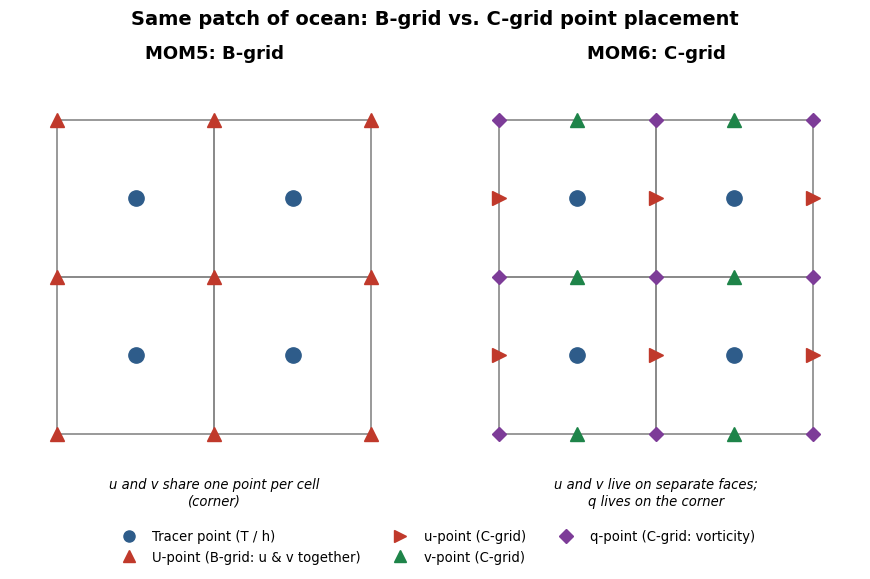

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.8))

ax = axes[0]
setup_axes(ax, (-0.3, 2.3), (-0.3, 2.3), "MOM5: B-grid")
for i in range(2):
    for j in range(2):
        ax.add_patch(mpatches.Rectangle((i, j), 1, 1, fill=False,
                                         edgecolor=GRID_COLOR, linewidth=1.2))
        ax.plot(i + 0.5, j + 0.5, "o", color=T_COLOR, markersize=11, zorder=5)
for i in range(3):
    for j in range(3):
        ax.plot(i, j, "^", color=U_COLOR, markersize=10, zorder=5)
ax.text(1.0, -0.28, "u and v share one point per cell\n(corner)",
        ha="center", va="top", fontsize=9.5, style="italic")

ax = axes[1]
setup_axes(ax, (-0.3, 2.3), (-0.3, 2.3), "MOM6: C-grid")
for i in range(2):
    for j in range(2):
        ax.add_patch(mpatches.Rectangle((i, j), 1, 1, fill=False,
                                         edgecolor=GRID_COLOR, linewidth=1.2))
        ax.plot(i + 0.5, j + 0.5, "o", color=T_COLOR, markersize=11, zorder=5)
for i in range(3):
    for j in range(2):
        ax.plot(i, j + 0.5, ">", color=U_COLOR, markersize=10, zorder=5)
for i in range(2):
    for j in range(3):
        ax.plot(i + 0.5, j, "^", color=V_COLOR, markersize=10, zorder=5)
for i in range(3):
    for j in range(3):
        ax.plot(i, j, "D", color=Q_COLOR, markersize=7, zorder=5)
ax.text(1.0, -0.28, "u and v live on separate faces;\nq lives on the corner",
        ha="center", va="top", fontsize=9.5, style="italic")

# Shared legend for both panels (proxy artists -- nothing is actually
# plotted at these locations, they only exist to build the legend)
legend_handles = [
    plt.Line2D([], [], marker="o", color=T_COLOR, linestyle="", markersize=8,
               label="Tracer point (T / h)"),
    plt.Line2D([], [], marker="^", color=U_COLOR, linestyle="", markersize=8,
               label="U-point (B-grid: u & v together)"),
    plt.Line2D([], [], marker=">", color=U_COLOR, linestyle="", markersize=8,
               label="u-point (C-grid)"),
    plt.Line2D([], [], marker="^", color=V_COLOR, linestyle="", markersize=8,
               label="v-point (C-grid)"),
    plt.Line2D([], [], marker="D", color=Q_COLOR, linestyle="", markersize=7,
               label="q-point (C-grid: vorticity)"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=3,
           bbox_to_anchor=(0.5, -0.16), frameon=False, fontsize=9.5)

fig.suptitle("Same patch of ocean: B-grid vs. C-grid point placement",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

Below is a comparison of the MOM5 Arakawa B-grid and MOM6 Arakawa C-grid: where each variable is stored, its offset from the tracer point, and the corresponding NetCDF dimension names.

| | MOM5 (B-grid) | MOM6 (C-grid) |
|---|---|---|
| Tracer point | T | h |
| Zonal velocity point | U (shared with v) | u (own point, on E/W face) |
| Meridional velocity point | U (shared with u) | v (own point, on N/S face) |
| Vorticity / corner point | (coincides with U) | q |
| Distance from tracer point to velocity point | half cell **diagonally** | half cell **along one axis** |
| Common dimension naming | `xt_ocean`/`yt_ocean` (T), `xu_ocean`/`yu_ocean` (U, both u & v) | `xh`/`yh` (h), `xq`/`yh` & `xh`/`yq` mix (u, v), `xq`/`yq` (q) |


We'll now look at the MOM5 B-grid and MOM6 C-grid separately in more detail.

## The MOM5 Arakawa B-grid

MOM5 discretises the ocean using two "families" of points, described in
the [MOM5 manual](https://mom-ocean.github.io/assets/pdfs/MOM5_manual.pdf)
as **T-cells** and **U-cells**:

- **T-cell** (tracer cell): centred on a **T-point**, where scalar
  quantities live — potential temperature, salinity, layer thickness,
  density, pressure, sea-surface height, and (in output) most tracer
  diagnostics.
- **U-cell** (velocity cell): centred on a **U-point**, offset by
  half a grid cell to the north-east of the corresponding T-point.
  **Both** velocity components, $u$ and $v$, are stored **at the same
  U-point** — this is the defining feature of a B-grid.

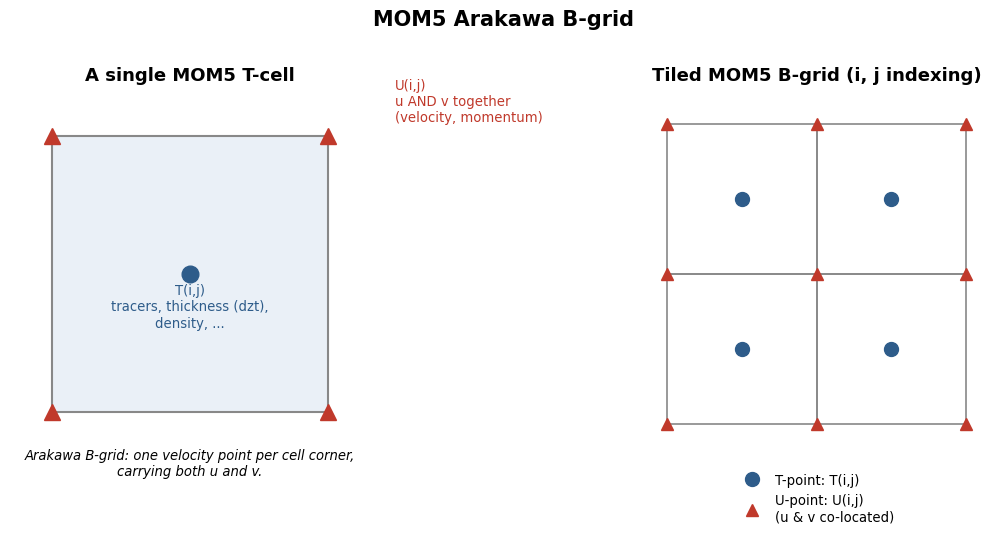

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))

# --- Left panel: single T-cell with its four surrounding U points ---
ax = axes[0]
setup_axes(ax, (-0.15, 1.15), (-0.15, 1.15), "A single MOM5 T-cell")

rect = mpatches.Rectangle((0, 0), 1, 1, fill=True, facecolor="#EAF0F7",
                           edgecolor=GRID_COLOR, linewidth=1.5)
ax.add_patch(rect)

ax.plot(0.5, 0.5, "o", color=T_COLOR, markersize=12, zorder=5)
ax.annotate("T(i,j)\ntracers, thickness (dzt),\ndensity, ...", (0.5, 0.5),
            textcoords="offset points", xytext=(0, -38),
            ha="center", fontsize=9.5, color=T_COLOR)

for (x, y) in [(0, 0), (1, 0), (0, 1), (1, 1)]:
    ax.plot(x, y, "^", color=U_COLOR, markersize=11, zorder=5)
ax.annotate("U(i,j)\nu AND v together\n(velocity, momentum)",
            (1, 1), textcoords="offset points", xytext=(48, 10),
            ha="left", fontsize=9.5, color=U_COLOR)

ax.text(0.5, -0.13, "Arakawa B-grid: one velocity point per cell corner,\n"
                     "carrying both u and v.", ha="center", va="top",
        fontsize=9.5, style="italic", transform=ax.transData)

# --- Right panel: tiled B-grid, several cells, showing indexing ---
ax = axes[1]
setup_axes(ax, (-0.2, 2.2), (-0.2, 2.2), "Tiled MOM5 B-grid (i, j indexing)")

for i in range(2):
    for j in range(2):
        rect = mpatches.Rectangle((i, j), 1, 1, fill=False,
                                   edgecolor=GRID_COLOR, linewidth=1.2)
        ax.add_patch(rect)
        ax.plot(i + 0.5, j + 0.5, "o", color=T_COLOR, markersize=10, zorder=5)

for i in range(3):
    for j in range(3):
        ax.plot(i, j, "^", color=U_COLOR, markersize=9, zorder=5)

ax.plot([], [], "o", color=T_COLOR, markersize=10, label="T-point: T(i,j)")
ax.plot([], [], "^", color=U_COLOR, markersize=9, label="U-point: U(i,j)\n(u & v co-located)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=1,
          frameon=False, fontsize=9.5)

fig.suptitle("MOM5 Arakawa B-grid", fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

**Key point:** on the B-grid there is only *one* type of velocity point.
$u$ and $v$ are co-located, which makes some operations (e.g.
computing kinetic energy, or rotating velocities) simple — but it also
means $u$ and $v$ are offset from the tracer point by a full half grid cell
in *both* directions, so computing quantities like the divergence of
velocity at a T-point, or advecting a tracer, requires interpolation.

### Notation you will meet in MOM5 / ACCESS-OM2 output

MOM5-based output (e.g. ACCESS-OM2) typically uses these dimension/variable
name conventions for giving the location of the grid points:

| Symbol (MOM5 manual) | Typical NetCDF dimension | Meaning |
|---|---|---|
| T-point, longitude | `xt_ocean` | tracer-point generalized longitude |
| T-point, latitude | `yt_ocean` | tracer-point generalized latitude |
| U-point, longitude | `xu_ocean` | velocity-point generalized longitude |
| U-point, latitude | `yu_ocean` | velocity-point generalized latitude |
| vertical level (mid-cell) | `st_ocean` | depth level — used by **both** tracers and horizontal velocity, since MOM5 only staggers horizontally; there is no separate vertical dimension for the U-point |
| vertical level (interface) | `sw_ocean` | depth of layer interfaces, e.g. for vertical velocity or diffusivities — unrelated to the horizontal T/U staggering |

**A tripolar-grid subtlety:** `xt_ocean`/`yt_ocean` and `xu_ocean`/`yu_ocean` are *generalized* curvilinear
coordinates, not true longitude/latitude — ACCESS-OM2's tripolar grid bends away from
simple lon-lat north of about 65°N. For correct geography (e.g. contour or
pcolormesh plots, especially in the Arctic), use the 2-D fields `geolon_t`/`geolat_t`
(true lon/lat of T-points) and `geolon_c`/`geolat_c` (true lon/lat of the
corner/U-points) instead of treating `xt_ocean`/`xu_ocean` as if they were longitude.
This is exactly what the real
[`Relative_Vorticity.ipynb`](https://github.com/COSIMA/cosima-recipes/blob/main/03-Advanced-Recipes/Relative_Vorticity.ipynb)
recipe does when it plots against `geolon_c`/`geolat_c` rather than `xu_ocean`/`yu_ocean`.

Grid metrics (cell widths/areas) for MOM5/ACCESS-OM2 are provided in the
ocean grid file (commonly `ocean_grid.nc`), with variables such as
`area_t`, `area_u`, `dxt`, `dyt`, `dxu`, `dyu`, etc. — the
exact names depend on the grid-generation tool used, so **always check the
grid file that accompanies your experiment** rather than assuming names. The key thing to note is that each of those is associated with a grid point (e.g.  `dxt` is grid cell width at a T-point). A picture helps explain...

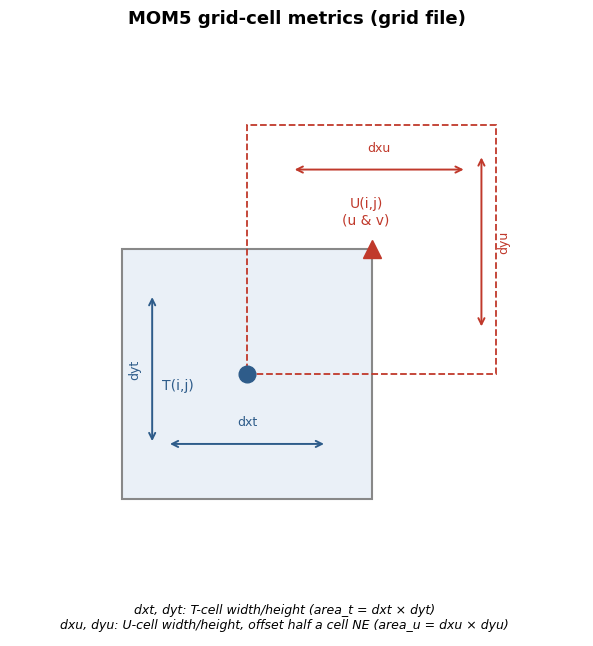

In [18]:
fig, ax = plt.subplots(figsize=(7.0, 6.6))
setup_axes(ax, (-0.45, 1.85), (-0.55, 1.85), "MOM5 grid-cell metrics (grid file)")

# T-cell (solid) centred on the T-point
rect_t = mpatches.Rectangle((0, 0), 1, 1, fill=True, facecolor="#EAF0F7",
                             edgecolor=GRID_COLOR, linewidth=1.5)
ax.add_patch(rect_t)

# U-cell (dashed) centred on the U-point, offset half a cell to the NE
rect_u = mpatches.Rectangle((0.5, 0.5), 1, 1, fill=False,
                             edgecolor=U_COLOR, linewidth=1.3, linestyle="--")
ax.add_patch(rect_u)

ax.plot(0.5, 0.5, "o", color=T_COLOR, markersize=12, zorder=5)
ax.annotate("T(i,j)", (0.5, 0.5), textcoords="offset points",
            xytext=(-38, -8), ha="right", va="center", fontsize=10, color=T_COLOR)

ax.annotate("", xy=(0.82, 0.22), xytext=(0.18, 0.22),
            arrowprops=dict(arrowstyle="<->", color=T_COLOR, lw=1.4))
ax.text(0.5, 0.28, "dxt", ha="center", va="bottom", color=T_COLOR, fontsize=9)
ax.annotate("", xy=(0.12, 0.82), xytext=(0.12, 0.22),
            arrowprops=dict(arrowstyle="<->", color=T_COLOR, lw=1.4))
ax.text(0.05, 0.52, "dyt", ha="center", va="center", color=T_COLOR, fontsize=9, rotation=90)

ax.plot(1, 1, "^", color=U_COLOR, markersize=13, zorder=5)
ax.annotate("U(i,j)\n(u & v)", (1, 1), textcoords="offset points",
            xytext=(-4, 16), ha="center", va="bottom", color=U_COLOR, fontsize=10)

ax.annotate("", xy=(1.38, 1.32), xytext=(0.68, 1.32),
            arrowprops=dict(arrowstyle="<->", color=U_COLOR, lw=1.4))
ax.text(1.03, 1.38, "dxu", ha="center", va="bottom", color=U_COLOR, fontsize=9)
ax.annotate("", xy=(1.44, 1.38), xytext=(1.44, 0.68),
            arrowprops=dict(arrowstyle="<->", color=U_COLOR, lw=1.4))
ax.text(1.53, 1.03, "dyu", ha="center", va="center", color=U_COLOR, fontsize=9, rotation=90)

ax.text(0.65, -0.42,
        "dxt, dyt: T-cell width/height (area_t = dxt \u00d7 dyt)\n"
        "dxu, dyu: U-cell width/height, offset half a cell NE (area_u = dxu \u00d7 dyu)",
        ha="center", va="top", fontsize=9, style="italic")

fig.tight_layout()
plt.show()

Note the `U`-cell (dashed) is offset by half a grid cell to the north-east
of the `T`-cell — `dxu`/`dyu` describe the width/height of *that* cell, not
the `T`-cell, so `area_u = dxu * dyu` should be used (not `area_t`) for any
integral or average taken over velocity-point quantities.

**Warning**: one should not try and calculate area using a formula such as `area_t = dxt*dyt` as this assumes that the grid is rectangular, this is not the case for OM2 and OM3 simulations!

### Seeing the B-grid in real ACCESS-OM2 output: the supergrid

The schematic above is easiest to trust once you've seen it in real grid
data — and the clearest place to see it is the **supergrid**. The supergrid has twice more resolution than the output files because it stores *every* point family — T-points and U-points for MOM5, or h/u/v/q for MOM6 — as one single
fine mesh. 

The supergrid is an input file, so unlike the diagnostics used elsewhere in this
tutorial it isn't part of the ACCESS-NRI intake catalog's per-variable
search — one needs to open it directly from its path. Here is the real file behind
the standard 1° ACCESS-OM2 configuration:

In [2]:
import xarray as xr

# The real 1-degree ACCESS-OM2 supergrid -- unfortunately not a lot of provenance metatdata inside it!
supergrid_path = ("/g/data/vk83/experiments/inputs/access-om2/ocean/grids/"
                   "mosaic/global.1deg/2020.05.30/ocean_hgrid.nc")
supergrid = xr.open_dataset(supergrid_path)
supergrid

<xarray.Dataset> Size: 21MB
Dimensions:   (nyp: 601, nxp: 721, nx: 720, ny: 600)
Dimensions without coordinates: nyp, nxp, nx, ny
Data variables:
    tile      |S255 255B ...
    x         (nyp, nxp) float64 3MB ...
    y         (nyp, nxp) float64 3MB ...
    dx        (nyp, nx) float64 3MB ...
    dy        (ny, nxp) float64 3MB ...
    angle_dx  (nyp, nxp) float64 3MB ...
    area      (ny, nx) float64 3MB ...

`supergrid.x` and `supergrid.y` hold the true longitude/latitude of
*every* point on the fine mesh. Reading every second row and column, with
an offset of 0 or 1, gives four families of points — and the B-grid uses
exactly two of them:

In [51]:
# T-points: odd row, odd column
T_lon, T_lat = supergrid.x[1::2, 1::2], supergrid.y[1::2, 1::2]

# U-points: even row, even column -- these are the *corners* of the
# supergrid mesh, and the B-grid puts both u and v here
U_lon, U_lat = supergrid.x[0::2, 0::2], supergrid.y[0::2, 0::2]

T_lon.shape, U_lon.shape

((300, 360), (301, 361))

And plotting both over a small patch shows the B-grid structure at the
model's own resolution, built directly from the same file MOM5's
grid-generation tools used.

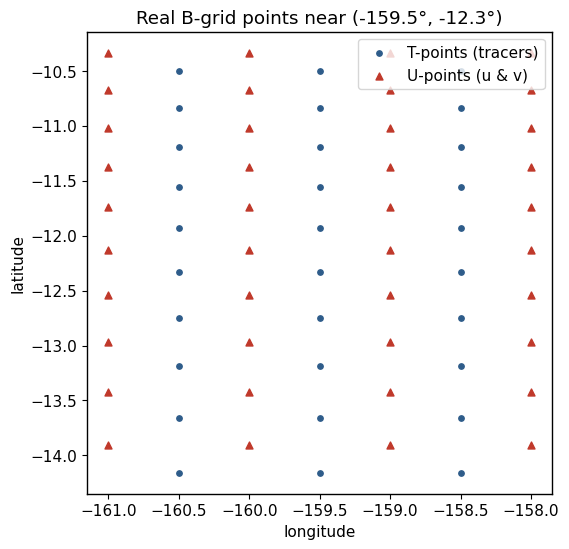

In [21]:
import matplotlib.pyplot as plt

# Pick a real point well inside the domain and build a small window
# around it, rather than guessing a longitude/latitude range up front

#Dividing each by 3 just picks an index — not a coordinate — roughly a third of the way into each dimension. 
#The only goal here is "not right at the edge of the array"; the exact fraction doesn't matter
anchor_j, anchor_i = T_lon.sizes["nyp"] // 3, T_lon.sizes["nxp"] // 3
anchor_lon = float(T_lon.isel(nyp=anchor_j, nxp=anchor_i))
anchor_lat = float(T_lat.isel(nyp=anchor_j, nxp=anchor_i))

lon_bounds = (anchor_lon - 2, anchor_lon + 2)
lat_bounds = (anchor_lat - 2, anchor_lat + 2)

def select_patch(lon_field, lat_field):
    mask = ((lon_field > lon_bounds[0]) & (lon_field < lon_bounds[1]) &
            (lat_field > lat_bounds[0]) & (lat_field < lat_bounds[1]))
    return lon_field.where(mask, drop=True), lat_field.where(mask, drop=True)

t_lon, t_lat = select_patch(T_lon, T_lat)
u_lon, u_lat = select_patch(U_lon, U_lat)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(t_lon, t_lat, color="#2E5C8A", s=15, label="T-points (tracers)")
ax.scatter(u_lon, u_lat, color="#C0392B", s=25, marker="^", label="U-points (u & v)")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title(f"Real B-grid points near ({anchor_lon:.1f}\u00b0, {anchor_lat:.1f}\u00b0)")
ax.legend();

In everyday analysis we think you should just use the *pre-computed* `geolon_t`/`geolat_t`/`geolon_c`/`geolat_c`
fields from the experiment's own grid file (as the real
[`Relative_Vorticity.ipynb`](https://github.com/COSIMA/cosima-recipes/blob/main/03-Advanced-Recipes/Relative_Vorticity.ipynb)
recipe does) but it's likely helpful to see what's happening under the hood.

To see a full calculation built on top of this — computing relative
vorticity exactly as MOM5 does internally, by differencing $u$ and $v$
across the B-grid cell and dividing by the north/east face widths built
from `dxu`/`dyu` — see
[`Relative_Vorticity.ipynb`](https://github.com/COSIMA/cosima-recipes/blob/main/03-Advanced-Recipes/Relative_Vorticity.ipynb).

---

## The MOM6 Arakawa C-grid

MOM6 uses the Arakawa C-grid, described in the
[MOM6 documentation on discrete grids](https://mom6.readthedocs.io/en/main/api/generated/pages/Discrete_Grids.html).
On the C-grid, each variable gets its **own** staggered location:

- **h-point** (tracer point): centre of the cell — thickness, temperature,
  salinity, and most tracer/scalar diagnostics.
- **u-point**: on the **east/west faces** of the h-cell — zonal velocity
  and zonal transports.
- **v-point**: on the **north/south faces** of the h-cell — meridional
  velocity and meridional transports.
- **q-point**: at the **corners** of the h-cell — relative vorticity,
  potential vorticity, and some viscosity/diffusivity diagnostics. (`q` is
  also called the "corner" or "Bu" — B-grid-like — point, since in MOM6's
  own C/D-grid formalism it plays the role that the B-grid velocity point
  historically played for vorticity.)

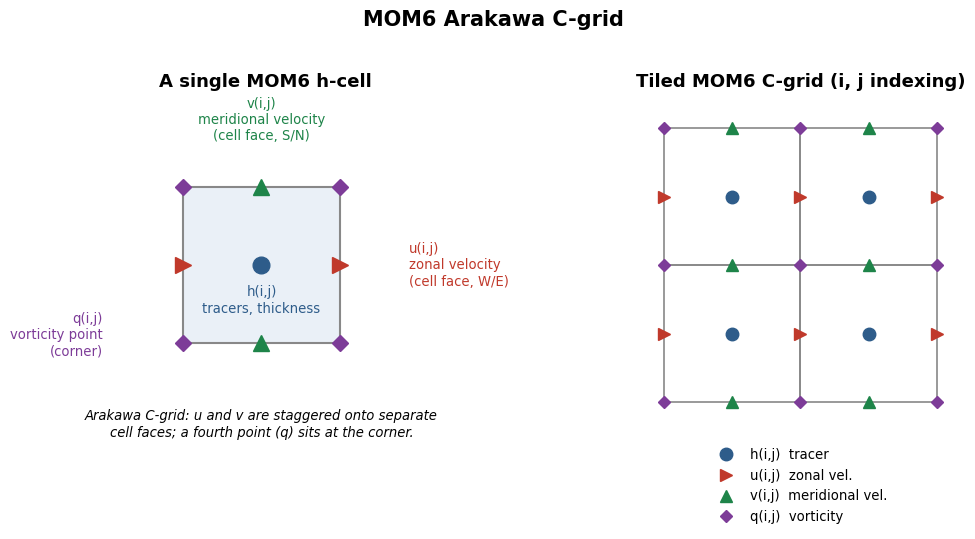

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))

# --- Left panel: single h-cell with u, v on faces and q on corners ---
ax = axes[0]
setup_axes(ax, (-0.4, 1.45), (-0.55, 1.55), "A single MOM6 h-cell")

rect = mpatches.Rectangle((0, 0), 1, 1, fill=True, facecolor="#EAF0F7",
                           edgecolor=GRID_COLOR, linewidth=1.5)
ax.add_patch(rect)

ax.plot(0.5, 0.5, "o", color=T_COLOR, markersize=12, zorder=5)
ax.annotate("h(i,j)\ntracers, thickness", (0.5, 0.5),
            textcoords="offset points", xytext=(0, -34),
            ha="center", fontsize=9.5, color=T_COLOR)

for x in [0, 1]:
    ax.plot(x, 0.5, ">", color=U_COLOR, markersize=11, zorder=5)
ax.annotate("u(i,j)\nzonal velocity\n(cell face, W/E)", (1, 0.5),
            textcoords="offset points", xytext=(50, 0),
            ha="left", va="center", fontsize=9.5, color=U_COLOR)

for y in [0, 1]:
    ax.plot(0.5, y, "^", color=V_COLOR, markersize=11, zorder=5)
ax.annotate("v(i,j)\nmeridional velocity\n(cell face, S/N)", (0.5, 1),
            textcoords="offset points", xytext=(0, 34),
            ha="center", fontsize=9.5, color=V_COLOR)

for (x, y) in [(0, 0), (1, 0), (0, 1), (1, 1)]:
    ax.plot(x, y, "D", color=Q_COLOR, markersize=8, zorder=5)
ax.annotate("q(i,j)\nvorticity point\n(corner)", (0, 0),
            textcoords="offset points", xytext=(-58, 6),
            ha="right", va="center", fontsize=9.5, color=Q_COLOR)

ax.text(0.5, -0.42, "Arakawa C-grid: u and v are staggered onto separate\n"
                     "cell faces; a fourth point (q) sits at the corner.",
        ha="center", va="top", fontsize=9.5, style="italic")

# --- Right panel: tiled C-grid ---
ax = axes[1]
setup_axes(ax, (-0.2, 2.2), (-0.2, 2.2), "Tiled MOM6 C-grid (i, j indexing)")

for i in range(2):
    for j in range(2):
        rect = mpatches.Rectangle((i, j), 1, 1, fill=False,
                                   edgecolor=GRID_COLOR, linewidth=1.2)
        ax.add_patch(rect)
        ax.plot(i + 0.5, j + 0.5, "o", color=T_COLOR, markersize=9, zorder=5)

for i in range(3):
    for j in range(2):
        ax.plot(i, j + 0.5, ">", color=U_COLOR, markersize=9, zorder=5)
for i in range(2):
    for j in range(3):
        ax.plot(i + 0.5, j, "^", color=V_COLOR, markersize=9, zorder=5)
for i in range(3):
    for j in range(3):
        ax.plot(i, j, "D", color=Q_COLOR, markersize=6.5, zorder=5)

ax.plot([], [], "o", color=T_COLOR, markersize=9, label="h(i,j)  tracer")
ax.plot([], [], ">", color=U_COLOR, markersize=9, label="u(i,j)  zonal vel.")
ax.plot([], [], "^", color=V_COLOR, markersize=9, label="v(i,j)  meridional vel.")
ax.plot([], [], "D", color=Q_COLOR, markersize=6.5, label="q(i,j)  vorticity")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=1,
          frameon=False, fontsize=9.5)

fig.suptitle("MOM6 Arakawa C-grid", fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

**Key point:** on the C-grid, $u$ and $v$ live at *different* locations —
each offset from the tracer point by only *half* a grid cell, in only
*one* direction. This makes the discrete divergence and gradient operators
much more compact and accurate (the classic argument for preferring the
C-grid over the B-grid at the grid scales used by ocean eddy-resolving
models). The cost is that even simple diagnostics — e.g. speed
$\sqrt{u^2+v^2}$ — require interpolating $u$ and $v$ onto a common point
before combining them.

### Notation you will meet in MOM6 / ACCESS-OM3 output

MOM6-based output (e.g. ACCESS-OM3) uses dimension names as follows:

| Symbol (MOM6 docs) | Typical NetCDF dimension | Meaning |
|---|---|---|
| h-point, longitude | `xh` | tracer-point ("h") longitude |
| h-point, latitude | `yh` | tracer-point ("h") latitude |
| corner (q/Bu) point, longitude | `xq` | corner-point longitude |
| corner (q/Bu) point, latitude | `yq` | corner-point latitude |
| vertical layer centre | `z_l` | mid-layer depth |
| vertical layer interface | `z_i` | interface depth |

Because $u$ lives on the east/west face, it shares the *y*-dimension with
`h` (`yh`) but the *x*-dimension with the corners (`xq`); $v$ is the
opposite. So in an actual ACCESS-OM3 output file you will see, e.g.:

```text
float uo(time, z_l, yh, xq) ;
        uo:long_name = "Sea Water X Velocity" ;
        uo:units = "m s-1" ;
double xq(xq) ;
        xq:long_name = "q point nominal longitude" ;
double yh(yh) ;
        yh:long_name = "h point nominal latitude" ;
```

This "mixed" dimension naming (`yh, xq` for `u`; `yq, xh` for `v`) is the
single most distinctive fingerprint of C-grid output, and is very
different from MOM5's separate `xu_ocean`/`yu_ocean` pair used for *both*
components of velocity.

**A detail that ties back to the previous section:** open an actual
`*.mom6.static.nc` file and look at the `long_name` attributes — MOM6
itself labels the h-point coordinates "**T** points", the u-point
coordinates "zonal velocity (**Cu**) points", the v-point coordinates
"meridional velocity (**Cv**) points", and the corner/q-point coordinates
"corner (**Bu**) points". So even inside a C-grid model, the historical
B-grid vocabulary (T, "Bu" for the B-grid-like corner point) survives in
the metadata — it's the same underlying naming heritage as MOM5's T/U
points, just split across four locations instead of two.

**Mass transport vs. velocity:** MOM6 output distinguishes *velocity*
diagnostics from *transport* diagnostics by name. `uo`/`vo` are velocities
(m s⁻¹, CMOR-style names for `sea_water_x_velocity`/`sea_water_y_velocity`),
on the `u`/`v` points described above. `umo`/`vmo` are the corresponding
**mass transports** (kg s⁻¹, one value per layer) — MOM6's own diagnostic
manager registers these as the transport already integrated across the
whole cell face width, and already including any parameterised eddy
transport (e.g. from the Gent-McWilliams scheme) within each layer's
value. This matters in practice: the
[`Overturning_Circulation.ipynb`](https://github.com/COSIMA/cosima-recipes/blob/main/03-Advanced-Recipes/Overturning_Circulation.ipynb)
recipe can cumulatively sum `vmo` directly to build the overturning
streamfunction, whereas the equivalent MOM5 quantity, the resolved
transport `ty_trans_rho`, needs the parameterised eddy transport
(`ty_trans_rho_gm`) added in by hand *before* that same cumulative sum — a
good concrete example of why a MOM5 recipe can't just be pointed at MOM6
output (more on this in Section 5).

**Symmetric vs. non-symmetric memory:** you may also notice that the
corner/velocity dimensions (`xq`, `yq`) can have one *more* point than the
tracer dimensions (`xh`, `yh`) — e.g. `xh = 1440` against `xq = 1441` for a
particular ACCESS-OM3 configuration. This is because MOM6 can be run and
output in "symmetric" memory mode, where the corner/face arrays fully
bracket the tracer array, rather than "non-symmetric" mode where they
don't. See the
[MOM6 documentation's indexing figures](https://mom6.readthedocs.io/en/main/api/generated/pages/Discrete_Grids.html)
if you run into off-by-one issues when combining `h`, `u`, `v`, and `q`
point arrays.

### Where to find MOM6/OM3 grid geometry

The `*.mom6.static.nc` file written alongside your run (or the
`ocean_static.nc`/`ocean_hgrid.nc` companion files in some configurations)
contains everything you need to do offline diagnostics correctly:

- **Coordinates at every point type:** `geolon`, `geolat` (h-points, "T
  points" in the file's own `long_name`), `geolon_u`, `geolat_u` (u-points,
  "Cu points"), `geolon_v`, `geolat_v` (v-points, "Cv points"), `geolon_c`,
  `geolat_c` (corner/q-points, "Bu points").
- **Cell widths:** `dxt`, `dyt` (h-cell), `dxCu`, `dyCu` (u-point),
  `dxCv`, `dyCv` (v-point) — these are the metrics you need for computing
  gradients, transports through a section, or line integrals.
- **Cell areas:** `areacello` (h-cell), `areacello_cu`, `areacello_cv`,
  `areacello_bu` (corner-cell area) — needed for area integrals/means and
  for converting between fluxes and flux *densities*.
- **Bathymetry:** `deptho`.

These metrics aren't independently measured — they're built from the
supergrid too. The supergrid file itself carries `dx`/`dy`/`area` at its
own (double) resolution, and (per the
[MOM6 documentation](https://mom6.readthedocs.io/en/main/api/generated/pages/Discrete_Grids.html))
`areaT` and `areaBu` (i.e. `areacello` and `areacello_bu`) are literally
the sum of the four supergrid cell areas surrounding each h-point and
q-point respectively. Same underlying file, every time.

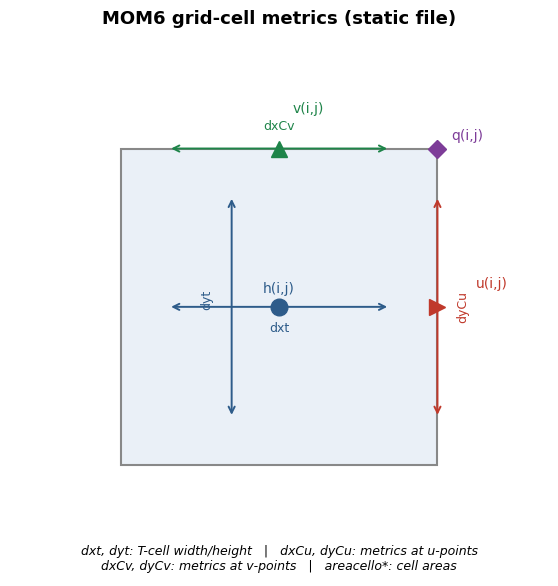

In [31]:
fig, ax = plt.subplots(figsize=(6.4, 6.0))
setup_axes(ax, (-0.35, 1.35), (-0.35, 1.35), "MOM6 grid-cell metrics (static file)")

rect = mpatches.Rectangle((0, 0), 1, 1, fill=True, facecolor="#EAF0F7",
                           edgecolor=GRID_COLOR, linewidth=1.5)
ax.add_patch(rect)

ax.plot(0.5, 0.5, "o", color=T_COLOR, markersize=12, zorder=5)
ax.annotate("h(i,j)", (0.5, 0.5), textcoords="offset points",
            xytext=(0, 10), ha="center", fontsize=10, color=T_COLOR)

ax.annotate("", xy=(0.85, 0.5), xytext=(0.15, 0.5),
            arrowprops=dict(arrowstyle="<->", color=T_COLOR, lw=1.4))
ax.text(0.5, 0.42, "dxt", ha="center", color=T_COLOR, fontsize=9)
ax.annotate("", xy=(0.35, 0.85), xytext=(0.35, 0.15),
            arrowprops=dict(arrowstyle="<->", color=T_COLOR, lw=1.4))
ax.text(0.27, 0.5, "dyt", ha="center", color=T_COLOR, fontsize=9, rotation=90)

ax.plot(1, 0.5, ">", color=U_COLOR, markersize=12, zorder=5)
ax.annotate("u(i,j)", (1, 0.5), textcoords="offset points",
            xytext=(28, 14), ha="left", color=U_COLOR, fontsize=10)
ax.annotate("", xy=(1, 0.85), xytext=(1, 0.15),
            arrowprops=dict(arrowstyle="<->", color=U_COLOR, lw=1.4))
ax.text(1.06, 0.5, "dyCu", color=U_COLOR, fontsize=9, rotation=90, va="center")

ax.plot(0.5, 1, "^", color=V_COLOR, markersize=12, zorder=5)
ax.annotate("v(i,j)", (0.5, 1), textcoords="offset points",
            xytext=(10, 26), ha="left", color=V_COLOR, fontsize=10)
ax.annotate("", xy=(0.85, 1), xytext=(0.15, 1),
            arrowprops=dict(arrowstyle="<->", color=V_COLOR, lw=1.4))
ax.text(0.5, 1.06, "dxCv", color=V_COLOR, fontsize=9, ha="center")

ax.plot(1, 1, "D", color=Q_COLOR, markersize=9, zorder=5)
ax.annotate("q(i,j)", (1, 1), textcoords="offset points",
            xytext=(10, 6), ha="left", color=Q_COLOR, fontsize=10)

ax.text(0.5, -0.25,
        "dxt, dyt: T-cell width/height   |   dxCu, dyCu: metrics at u-points\n"
        "dxCv, dyCv: metrics at v-points   |   areacello*: cell areas",
        ha="center", va="top", fontsize=9, style="italic")

fig.tight_layout()
plt.show()

### Seeing the C-grid in real ACCESS-OM3/MOM6 output: the supergrid

As with the B-grid above, the clearest place to see the C-grid structure
is the supergrid — it's also something the model reads at start-up
(`GRID_FILE = "ocean_hgrid.nc"` in `MOM_input`). For further details see [28 minutes in this video](https://www.youtube.com/watch?v=SUMjB5jX_dE). Here is the real file
behind the 25 km ACCESS-OM3 configuration:

In [1]:
import xarray as xr

# The real 25 km ACCESS-OM3 supergrid -- the exact file MOM6 itself reads
# at runtime as GRID_FILE in MOM_input
supergrid_path = ("/g/data/vk83/configurations/inputs/access-om3/mom/grids/mosaic/global.25km/2025.09.02/ocean_hgrid.nc")
supergrid = xr.open_dataset(supergrid_path)
supergrid

<xarray.Dataset> Size: 319MB
Dimensions:   (nyp: 2305, nxp: 2881, ny: 2304, nx: 2880)
Dimensions without coordinates: nyp, nxp, ny, nx
Data variables:
    tile      |S255 255B ...
    y         (nyp, nxp) float64 53MB ...
    x         (nyp, nxp) float64 53MB ...
    dy        (ny, nxp) float64 53MB ...
    dx        (nyp, nx) float64 53MB ...
    area      (ny, nx) float64 53MB ...
    angle_dx  (nyp, nxp) float64 53MB ...
Attributes:
    history:      This grid file was generated via command ocean_grid_generat...
    description:  This is an orthogonal coordinate grid for the Earth with a ...
    source:       ocean_grid_generator.py had git hash 2e945eb6a0e0d2d2bd983b...

This is the *same kind* of file as the MOM5 supergrid above — but now we
read out **all four** point families, because the C-grid uses all four:

In [25]:
h_lon, h_lat = supergrid.x[1::2, 1::2], supergrid.y[1::2, 1::2]  # h: odd, odd
u_lon, u_lat = supergrid.x[1::2, 0::2], supergrid.y[1::2, 0::2]  # u: odd row, even col
v_lon, v_lat = supergrid.x[0::2, 1::2], supergrid.y[0::2, 1::2]  # v: even row, odd col
q_lon, q_lat = supergrid.x[0::2, 0::2], supergrid.y[0::2, 0::2]  # q: even, even (corners)

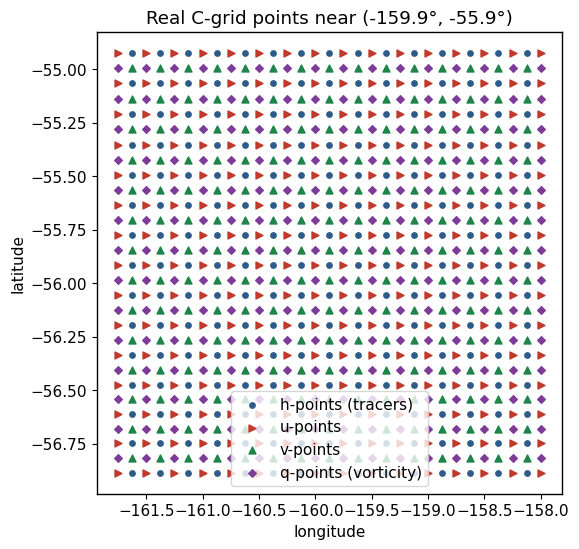

In [26]:
import matplotlib.pyplot as plt

# As in Section 2, pick a real point from the data and build a small
# window around it rather than guessing a longitude/latitude range --
# this grid's own longitude convention isn't guaranteed to match the
# MOM5 supergrid's, since it comes from a different generation tool
# (real tripolar/bipolar-cap grids commonly use a shifted range such as
# -280 to 80 or -300 to 60, not plain 0-360 or -180/180).
anchor_j, anchor_i = h_lon.sizes["nyp"] // 4, h_lon.sizes["nxp"] // 3
anchor_lon = float(h_lon.isel(nyp=anchor_j, nxp=anchor_i))
anchor_lat = float(h_lat.isel(nyp=anchor_j, nxp=anchor_i))

lon_bounds = (anchor_lon - 2, anchor_lon + 2)
lat_bounds = (anchor_lat - 1, anchor_lat + 1)

def select_patch(lon_field, lat_field):
    mask = ((lon_field > lon_bounds[0]) & (lon_field < lon_bounds[1]) &
            (lat_field > lat_bounds[0]) & (lat_field < lat_bounds[1]))
    return lon_field.where(mask, drop=True), lat_field.where(mask, drop=True)

h_lon_p, h_lat_p = select_patch(h_lon, h_lat)
u_lon_p, u_lat_p = select_patch(u_lon, u_lat)
v_lon_p, v_lat_p = select_patch(v_lon, v_lat)
q_lon_p, q_lat_p = select_patch(q_lon, q_lat)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(h_lon_p, h_lat_p, color="#2E5C8A", s=15, label="h-points (tracers)")
ax.scatter(u_lon_p, u_lat_p, color="#C0392B", s=25, marker=">", label="u-points")
ax.scatter(v_lon_p, v_lat_p, color="#1E8449", s=25, marker="^", label="v-points")
ax.scatter(q_lon_p, q_lat_p, color="#7D3C98", s=15, marker="D", label="q-points (vorticity)")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title(f"Real C-grid points near ({anchor_lon:.1f}\u00b0, {anchor_lat:.1f}\u00b0)")
ax.legend();

**Rule of thumb:** *never* assume you can reuse a `dxt`/`area_t`-type
metric computed for one point type at another point type — always pull the
metric that matches the point where your variable of interest is defined.

## Practical consequences for analysis

1. **You cannot simply subtract/add MOM5 and MOM6 fields**, even of the
   "same" physical quantity, without first regridding them onto a common
   point/grid — their native points don't coincide.
2. **It is dangerous to naively combine variables** (e.g. to get speed or
   kinetic energy, or to rotate velocities into along-/across-slope
   components) without first interpolating them onto the same point. On
   the C-grid this typically means interpolating `u` and `v` onto the
   `h`-point; on the B-grid, `u` and `v` are already co-located at the
   `U`-point, but are offset from `T`.
3. **Fluxes through a section should use the velocity/transport point
   that lies on that section**, together with the matching metric
   (`dyCu`/`dxCv` for MOM6, `dyu`/`dxu`-type quantities for MOM5), not an
   interpolated or nearby point.
4. **cell area for spatial averages/integrals** must match the point type
   of the variable (`areacello` for `h`, `areacello_cu` for `u`, etc., in
   MOM6; `area_t`/`area_u` in MOM5).
5. **Recipes are not directly portable between MOM5 and MOM6.** A COSIMA
   recipe written against ACCESS-OM2 (MOM5) output will reference
   `xt_ocean`/`xu_ocean`-style dimensions and MOM5 grid files; the same
   analysis on ACCESS-OM3 (MOM6) output needs to be rewritten against
   `xh`/`xq`-style dimensions and the MOM6 static file. It's not just a
   renaming exercise, either: the *same physical diagnostic* can be
   assembled differently on each model. For example, to build the
   meridional overturning streamfunction, MOM5 output requires you to add
   the parameterised eddy transport (`ty_trans_rho_gm`) to the resolved
   transport (`ty_trans_rho`) by hand, whereas MOM6's `vmo` already has
   this included — see the real
   [`Overturning_Circulation.ipynb`](https://github.com/COSIMA/cosima-recipes/blob/main/03-Advanced-Recipes/Overturning_Circulation.ipynb)
   recipe, which documents exactly this adaptation in its opening cell.
   This is why `cosima-recipes` no longer aims to have single recipes that
   work unmodified on both models — instead, recipes should note briefly
   near the top how a user would adapt the code for the other grid.
6. **Both models' horizontal coordinates are curvilinear, not true
   lon/lat, over at least part of the domain** (MOM5's tripolar grid north
   of ~65°N; MOM6/ACCESS-OM3 grids can have similar regions depending on
   configuration). This affects more than plotting: a local "$x$-direction"
   quantity like `u` is only a true zonal velocity where grid lines are
   aligned with latitude circles. The real `Overturning_Circulation.ipynb`
   recipe flags exactly this — its zonal-sum calculation is only valid
   south of 65°N, because north of there the model's local $x$/$y$
   directions no longer line up with true east/north.

---

## `xgcm`: staggered-grid-aware analysis in Python

This is a more advanced topic than the above material, so you may wish to come back to this after you've had some experience working with MOM5 and MOM6 output. Manually keeping track of which point every variable lives on, and
manually interpolating/differentiating with the correct metrics, becomes
tedious and error-prone very quickly. [`xgcm`](https://xgcm.readthedocs.io/)
is a Python package built on top of `xarray` that:

- represents a staggered grid (B, C, or otherwise) as a formal `xgcm.Grid`
  object, with named axes (`X`, `Y`, `Z`) and named positions along each
  axis (`center`, `left`, `right`, `inner`, `outer`);
- provides grid-aware `interp`, `diff`, `cumsum`, `derivative`, and
  `integrate` methods that automatically use the correct staggering and
  (if supplied) the correct metrics;
- has been used to build purpose-built utilities for both MOM5-family
  and MOM6-family grids — see, e.g., the
  [MOM6 analysis cookbook](https://mom6-analysiscookbook.readthedocs.io/en/latest/).

A minimal example of building an `xgcm.Grid` for MOM6-style output is below (more background [here](https://mom6-analysiscookbook.readthedocs.io/en/latest/notebooks/getting_started.html#Building-an-xgcm-grid-object) and [here](https://gallery.pangeo.io/repos/xgcm/xgcm-examples/03_MOM6.html)). Like
the code in the real recipes this is modelled on, `ds` here stands for
whatever dataset *you've* loaded and merged (velocity variables plus the
matching grid/metric variables) — these two snippets are illustrative,
not tied to a dataset loaded earlier in *this* notebook, so don't expect
them to run as part of a top-to-bottom "Run All":


```python
# NOTE: illustrative -- ds is a placeholder for your own loaded dataset;
# this snippet is not executed as part of this notebook.
# see https://gallery.pangeo.io/repos/xgcm/xgcm-examples/03_MOM6.html for more details
import xgcm

grid = xgcm.Grid(
    ds,
    coords={
        "X": {"center": "xh", "right": "xq"},
        "Y": {"center": "yh", "right": "yq"},
        "Z": {"center": "z_l", "outer": "z_i"},
    },
    periodic=["X"],
)

# interpolate u (on xq, yh) and v (on xh, yq) onto the tracer point (xh, yh).
# X is periodic (no boundary= needed); Y is not, so -- as in the MOM5
# example below -- the Y-interpolation needs a boundary policy or it can
# raise an error right at the domain edge.
u_on_h = grid.interp(ds["uo"], "X")
v_on_h = grid.interp(ds["vo"], "Y", boundary="extend")
speed  = (u_on_h**2 + v_on_h**2) ** 0.5
```


The equivalent for MOM5-style B-grid output looks like this — and it's
worth comparing carefully to the MOM6 example above, because it shows the
B-grid/C-grid distinction directly in code. On the C-grid, each velocity
component is shifted along *one* axis only (`u` shifts in `X`, `v` shifts
in `Y`). On the B-grid, the *same* `U`-point is shifted in **both** `X`
and `Y` at once, because a single point carries both velocity components:


```python
# NOTE: illustrative -- ds is a placeholder for your own loaded dataset;
# this snippet is not executed as part of this notebook.
ds.coords["xt_ocean"].attrs.update(axis="X")
ds.coords["xu_ocean"].attrs.update(axis="X", c_grid_axis_shift=0.5)
ds.coords["yt_ocean"].attrs.update(axis="Y")
ds.coords["yu_ocean"].attrs.update(axis="Y", c_grid_axis_shift=0.5)

grid = xgcm.Grid(ds, periodic=["X"])

# interpolate u and v from the U-point onto the T-point along both axes
u_on_t = grid.interp(grid.interp(ds["u"], "X"), "Y", boundary="extend")
v_on_t = grid.interp(grid.interp(ds["v"], "X"), "Y", boundary="extend")
speed  = (u_on_t**2 + v_on_t**2) ** 0.5
```

This pattern — and the full, careful derivation of MOM5's relative
vorticity calculation using `xgcm` — is worked through in detail in the
real
[`Relative_Vorticity.ipynb`](https://github.com/COSIMA/cosima-recipes/blob/main/03-Advanced-Recipes/Relative_Vorticity.ipynb)
recipe, which is a natural next step after this tutorial. The `xgcm`
pattern shown above for MOM6 comes from
[xgcm's own MOM6 tutorial](https://xgcm.readthedocs.io/en/latest/xgcm-examples/03_MOM6.html)
and is used throughout the (third-party, non-COSIMA)
[MOM6 analysis cookbook](https://mom6-analysiscookbook.readthedocs.io/en/latest/notebooks/vorticity.html),
e.g. in its own vorticity and overturning notebooks. For a MOM6 worked
example that's part of this cookbook,
[`Overturning_Circulation.ipynb`](https://github.com/COSIMA/cosima-recipes/blob/main/03-Advanced-Recipes/Overturning_Circulation.ipynb)
is the natural next step — though note it takes a different route to its
answer, building the overturning streamfunction with a manual `.cumsum()`
rather than `xgcm`, so don't expect to see this section's coding pattern
reused there directly.



---

## 7. Summary

- MOM5 uses an **Arakawa B-grid**: tracers on `T`-points, both velocity
  components together on `U`-points at the cell corner.
- MOM6 uses an **Arakawa C-grid**: tracers on `h`-points, zonal velocity
  on `u`-points (E/W faces), meridional velocity on `v`-points (N/S
  faces), and vorticity on `q`-points (corners).
- The two grids use different NetCDF dimension-naming conventions
  (`xt_ocean`/`xu_ocean`, ... for MOM5 vs. `xh`/`xq`, ... for MOM6) — check
  the file's own metadata rather than assuming.
- Grid geometry (coordinates, cell widths, cell areas) for accurate
  offline diagnostics lives in a dedicated grid/static file for each
  model, and must be matched to the correct point type.
- `xgcm` provides a grid-aware, staggering-safe way to interpolate,
  difference and integrate fields on either grid.

## Further reading

**Worked examples in the COSIMA recipes** (natural next steps after this tutorial):

- [`Relative_Vorticity.ipynb`](https://github.com/COSIMA/cosima-recipes/blob/main/03-Advanced-Recipes/Relative_Vorticity.ipynb) —
  computes relative vorticity on MOM5's B-grid three ways (naïve, exactly
  as the model does it, and with `xgcm`), and compares them.
- [`Overturning_Circulation.ipynb`](https://github.com/COSIMA/cosima-recipes/blob/main/03-Advanced-Recipes/Overturning_Circulation.ipynb) —
  computes the meridional overturning streamfunction from MOM6 output, and
  spells out exactly what changes if you wanted the MOM5 equivalent.

**Background and reference:**

- [MOM5 manual](https://mom-ocean.github.io/assets/pdfs/MOM5_manual.pdf) —
  see the sections on the B-grid discretisation.
- [MOM6 documentation: Discrete Horizontal and Vertical Grids](https://mom6.readthedocs.io/en/main/api/generated/pages/Discrete_Grids.html)
- [A primer on MOM6 file structure (regional-mom6 docs)](https://regional-mom6.readthedocs.io/en/latest/mom6-file-structure-primer.html) —
  a clear explanation of `hgrid.nc`/the supergrid and the other files
  needed to run MOM6.
- [ACCESS-Hive: Run ACCESS-OM2](https://docs.access-hive.org.au/models/run_a_model/run_access-om2/) /
  [Run ACCESS-OM3](https://docs.access-hive.org.au/models/run_a_model/run_access-om3/) —
  documents the real input file paths (including `ocean_hgrid.nc`) used above.
- [decoding-om3 Season 1: OM3 runtime output files](https://decoding-access-om3.readthedocs.io/season1/#om3-runtime-output-files) —
  a walk-through of an actual ACCESS-OM3/MOM6 output directory, including
  a full `ncdump` of the static grid file, and how the model's own
  metadata labels each point type.
- [decoding-om3 issue #21: staggered grid locations and names](https://github.com/ACCESS-Community-Hub/decoding-om3/issues/21) —
  discussion of how different models name their staggered-grid points.
- [`xgcm` documentation](https://xgcm.readthedocs.io/)
- [MOM6 analysis cookbook](https://mom6-analysiscookbook.readthedocs.io/en/latest/) —
  including worked `xgcm`-based vorticity and overturning notebooks for
  MOM6 output.
- [MOM6 analysis tutorial](https://www.youtube.com/watch?v=SUMjB5jX_dE)